# STRAVA FITNESS PROJECT

### Submitted by: Parth Goyal

**Project Type** – Exploratory Data Analysis (EDA)  
**Contribution** – Individual  

# Bellabeat Fitness Data Analysis

## Table of Contents

1. [Project Summary](#Project-Summary)  
2. [Problem Statement](#Problem-Statement)  
3. [Business Objectives](#Business-Objectives)  
4. [SQL Data Analysis](#SQL-Data-Analysis) 
5. [Data Import into SQLite](#Data-Import-into-SQLite)  
6. [Data Cleaning](#Data-Cleaning)  
7. [Dataset Variables Description](#Dataset-Variables-Description)  
8. [Python Data Analysis](#Python-Data-Analysis)  
9. [Data Visualisation](#Data-Visualisation)  
10. [Tableau Dashboard](#Tableau-Dashboard)  
11. [Key Insights](#Key-Insights)  
12. [Business Insights](#Business-Insights)  
13. [Recommendations](#Recommendations)  
14. [Conclusion](#Conclusion)  

## Project Summary

Bellabeat is a high-tech wellness company that develops smart products designed to help women monitor and improve their health. The company collects data related to physical activity, sleep patterns, calories burned, and other health metrics through smart devices. Analyzing this data can provide valuable insights into user behavior and lifestyle patterns.
The objective of this project is to perform an exploratory data analysis (EDA) on smart fitness device data to understand how consumers use wearable health technology. The analysis focuses on identifying patterns in daily activity levels, sleep habits, and calorie expenditure. By cleaning and analyzing the dataset using Python (Pandas), SQL, and visualization tools such as Matplotlib and Seaborn, meaningful insights are extracted from the data.
The findings from this analysis help identify trends in user activity and health behaviors. These insights can support Bellabeat’s marketing team in developing data-driven strategies to improve product engagement and expand the company’s presence in the smart wellness device market.

## Github Link

## Problem Statement

Multiple datasets containing smart fitness device activity information are available for analysis. These datasets include data related to daily activity levels, steps taken, calories burned, sleep patterns, and other health metrics recorded by wearable devices.
The objective of this project is to merge and clean these datasets and perform Exploratory Data Analysis (EDA) to understand user behavior and activity patterns. By analyzing this data, meaningful insights can be generated about how people use smart fitness devices in their daily lives.
These insights will help identify trends in user activity, sleep habits, and calorie expenditure. The results can further support business decision-making and help wellness technology companies understand how to improve their products and marketing strategies.

## Business Objectives

The business objectives for analyzing the smart fitness datasets are as follows:
1. To analyze user activity data and identify trends in daily physical activities such as steps, distance, and calories burned.
2. To study sleep and activity patterns to understand how users maintain their health and fitness routines.
3. To discover behavioral patterns in smart device usage that can help improve user engagement.
4. To generate insights that can support marketing strategies and product improvements for wellness technology companies.
5. To visualize key patterns in the data using Python libraries such as Pandas, Matplotlib, and Seaborn.

## SQL Data Analysis

In this stage, SQL was used to clean and explore the raw fitness datasets.
Different datasets containing daily activity, sleep records, and calorie
information were analyzed using SQL queries.

The following steps were performed:

• Checking the number of records in each dataset  
• Identifying missing or null values  
• Removing duplicate records  
• Aggregating activity data such as average steps and calories burned  
• Joining multiple datasets to create a unified dataset for analysis


### Data Import into SQLite

The fitness datasets were initially provided in CSV format. 
To perform structured data analysis using SQL, the CSV files were imported into 
a SQLite database using **DB Browser for SQLite**.

SQLite provides an efficient way to store and query structured data using SQL 
queries, which helps in performing data exploration and cleaning before further 
analysis in Python.

#### Steps to Import CSV Files into SQLite

1. Open **DB Browser for SQLite**.
2. Create a new database file.
3. Select **Import → Table from CSV file**.
4. Choose the dataset CSV file.
5. Assign a table name for the dataset.
6. Verify column names and data types.
7. Repeat the process for all datasets.

The datasets were successfully imported as tables in the SQLite database 
for further analysis using SQL queries.

#### Tables Created in SQLite Database

The following datasets were imported as tables:

- dailyActivity_merged
- dailyCalories_merged
- dailyIntensities_merged
- dailySteps_merged
- hourlyCalories_merged
- hourlyIntensities_merged
- hourlySteps_merged
- sleepDay_merged
- weightLogInfo_merged

<img src="1.png" width="700"> 
The following screenshot shows how the tables were created in the SQLite database after importing the CSV datasets using DB Browser for SQLite.



Subsequently all other tables were added similarly

#### DataBase Structure

<img src="2.png" width="700"> 

### Data Cleaning

Before performing analysis, the datasets were cleaned to ensure accuracy and consistency. 
Data cleaning is an important step in the data analysis process as it helps identify 
missing values, duplicate records, and inconsistencies in the dataset.

SQL queries were used to inspect the datasets and verify the structure and quality 
of the data before further analysis.

#### Data Cleaning Steps

The following steps were performed during the data cleaning process:

1. Checked the structure of each dataset.
2. Verified the number of records in each table.
3. Checked for duplicate entries.
4. Verified the presence of missing or NULL values.
5. Ensured that column names and data types were consistent.
6. Confirmed that all datasets could be used for further analysis.

##### Checking Number of Records

```sql
SELECT COUNT(*) 
FROM dailyActivity_merged;
```

This query counts the total number of records in the dataset to understand 
the size of the data available for analysis.

##### Checking Duplicate Records

```sql
SELECT Id, ActivityDate, COUNT(*)
FROM dailyActivity_merged
GROUP BY Id, ActivityDate
HAVING COUNT(*) > 1;
```

This query helps identify duplicate entries in the dataset based on user ID 
and activity date.

##### Checking Missing Values

```sql
SELECT *
FROM dailyActivity_merged
WHERE TotalSteps IS NULL;
```

This query checks whether there are any missing values in the TotalSteps column.

##### For SleepDay Table:

##### Checking Duplicate Records

```sql
SELECT Id, SleepDay, COUNT(*) AS duplicate_count
FROM sleepDay_merged
GROUP BY Id, SleepDay
HAVING COUNT(*) > 1;
```

<img src="3.png" width="700"> 

Found 3 duplicate sleep records

##### Create a clean table without duplicates
```sql 
CREATE TABLE sleep_clean AS
SELECT DISTINCT *
FROM sleepDay_merged;


##### Verify Duplicates are gone 
```sql 
SELECT Id, SleepDay, COUNT(*) AS duplicate_count
FROM sleep_clean
GROUP BY Id, SleepDay
HAVING COUNT(*) > 1;

#### Data Cleaning Result

After performing the data cleaning steps, the datasets were verified to ensure 
that they contained valid and usable records for further analysis. The cleaned 
data was then used for exploratory analysis and visualization.

### Data Integration (Merge Tables)

The activity dataset was merged with the sleep dataset using the user ID to analyze relationships between physical activity and sleep patterns.

```sql 
CREATE TABLE activity_sleep AS
SELECT 
a.Id,
a.ActivityDate,
a.TotalSteps,
a.Calories,
a.VeryActiveMinutes,
a.FairlyActiveMinutes,
a.LightlyActiveMinutes,
s.TotalMinutesAsleep,
s.TotalTimeInBed
FROM dailyActivity_merged a
LEFT JOIN sleep_clean s
ON a.Id = s.Id;

This creates a new table activity_sleep.

Reason:

Activity data → steps, calories, distance

Sleep data → sleep duration

This allows analysis like:
1. Steps vs Sleep
2. Calories vs Sleep
3. Activity vs Sleep

## Dataset Variables Description

The following table describes the variables present in the dataset.

| Column | Description |
|------|------|
| Id | Unique ID |
| ActivityDate | Date of the activity |
| TotalSteps | Total steps taken by the user |
| TotalDistance | Total distance covered by the user |
| TrackerDistance | Distance tracked by the device |
| LoggedActivitiesDistance | Distance logged manually in the application |
| VeryActiveDistance_x | Very active distance (x dataset after merge) |
| ModeratelyActiveDistance_x | Moderately active distance (x dataset after merge) |
| LightActiveDistance_x | Light activity distance (x dataset after merge) |
| SedentaryActiveDistance_x | Sedentary activity distance (x dataset after merge) |
| VeryActiveMinutes_x | Minutes spent in very active activities (x dataset) |
| FairlyActiveMinutes_x | Minutes spent in fairly active activities (x dataset) |
| LightlyActiveMinutes_x | Minutes spent in light activities (x dataset) |
| SedentaryMinutes_x | Minutes spent in sedentary activity (x dataset) |
| Calories_x | Calories burned (x dataset) |
| ActivityDay_x | Activity date from x dataset |
| Calories_y | Calories burned (y dataset) |
| ActivityDay_y | Activity date from y dataset |
| SedentaryMinutes_y | Sedentary minutes from y dataset |
| LightlyActiveMinutes_y | Lightly active minutes from y dataset |
| FairlyActiveMinutes_y | Fairly active minutes from y dataset |
| VeryActiveMinutes_y | Very active minutes from y dataset |
| SedentaryActiveDistance_y | Sedentary activity distance from y dataset |
| LightActiveDistance_y | Light activity distance from y dataset |
| ModeratelyActiveDistance_y | Moderately active distance from y dataset |
| VeryActiveDistance_y | Very active distance from y dataset |
| ActivityDay | Day of the activity |
| StepTotal | Total steps recorded |
| SleepDay | Date of sleep record |
| TotalSleepRecords | Number of sleep records for the user |
| TotalMinutesAsleep | Total minutes the user was asleep |
| TotalTimeInBed | Total time user spent in bed |
| Date | Date of the record |
| WeightKg | Weight of the user in kilograms |
| WeightPounds | Weight of the user in pounds |
| Fat | Fat percentage of the user |
| BMI | Body Mass Index of the user |
| IsManualReport | Indicates if the record was manually reported |
| LogId | Unique log identifier |

## SQL Data Exploration

SQL queries were used to explore the datasets stored in the SQLite database. 
The purpose of this analysis is to understand user activity patterns such as 
daily steps, calorie expenditure, activity intensity, and sleep behavior.

These queries help extract useful insights from the data before performing 
visualization and further analysis using Python.

### Total Number of Records in Daily Activity Dataset

```sql
SELECT COUNT(*)
FROM dailyActivity_merged;
```

This query counts the total number of records in the daily activity dataset. 
It helps understand how many activity entries are available for analysis.

### Average Daily Steps

```sql
SELECT AVG(TotalSteps) AS Avg_Steps
FROM dailyActivity_merged;
```

This query calculates the average number of steps taken by users per day. 
It helps determine the overall activity level of users in the dataset.

### Average Calories Burned

```sql
SELECT AVG(Calories) AS Avg_Calories
FROM dailyActivity_merged;
```

This query calculates the average number of calories burned by users daily.

### Maximum Steps Recorded in a Day

```sql
SELECT MAX(TotalSteps) AS Max_Steps
FROM dailyActivity_merged;
```

This query identifies the highest number of steps recorded in a single day.

### Minimum Steps Recorded in a Day

```sql
SELECT MIN(TotalSteps) AS Min_Steps
FROM dailyActivity_merged;
```

This query finds the lowest number of steps recorded in the dataset.

### Most Active Users Based on Steps

```sql
SELECT Id, SUM(TotalSteps) AS Total_Steps
FROM dailyActivity_merged
GROUP BY Id
ORDER BY Total_Steps DESC
LIMIT 10;
```

This query identifies the users who recorded the highest number of total steps.

### Average Sleep Duration

```sql
SELECT AVG(TotalMinutesAsleep) AS Avg_Sleep
FROM sleepDay_merged;
```

This query calculates the average sleep duration of users.

### Average Sedentary Time

```sql
SELECT AVG(SedentaryMinutes) AS Avg_Sedentary
FROM dailyActivity_merged;
```

This query shows how much time users spend in sedentary activities on average.

### Steps Recorded Per Day

```sql
SELECT ActivityDate, SUM(TotalSteps) AS TotalSteps
FROM dailyActivity_merged
GROUP BY ActivityDate
ORDER BY ActivityDate;
```

This query shows how total steps vary across different days.

### Steps and Calories Relationship

```sql
SELECT TotalSteps, Calories
FROM dailyActivity_merged
ORDER BY TotalSteps DESC
LIMIT 20;
```

This query helps explore the relationship between steps taken and calories burned.

### Key Observations from SQL Analysis

• Users show a wide variation in daily step counts.  
• Higher step counts generally correspond with higher calorie burn.  
• Some users have very high sedentary minutes indicating low activity levels.  
• Sleep duration varies significantly across users.

## Python Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")

In [4]:
daily_activity = pd.read_csv("dailyActivity_merged.csv")
sleep = pd.read_csv("sleepDay_merged.csv")
hourly_steps = pd.read_csv("hourlySteps_merged.csv")
hourly_calories = pd.read_csv("hourlyCalories_merged.csv")

In [6]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [7]:
sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [8]:
daily_activity.shape
sleep.shape

(413, 5)

### Data Information

In [9]:
daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [11]:
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'], format='%m/%d/%Y')
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])

In [16]:
daily_activity.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Check Missing Values (Python Cleaning):

In [13]:
sleep.isnull().sum()

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

Remove Duplicate Rows (Sleep Dataset):

In [14]:
sleep = sleep.drop_duplicates()

Verify:

In [15]:
sleep.duplicated().sum()

0

Merge Activity and Sleep Data:

In [17]:
merged_df = pd.merge(daily_activity, sleep, on='Id', how='left')

In [18]:
merged_df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,1.0,327.0,346.0
1,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-13,2.0,384.0,407.0
2,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-15,1.0,412.0,442.0
3,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-16,2.0,340.0,367.0
4,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-17,1.0,700.0,712.0


### Basic Statistics

In [19]:
merged_df.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,1.257500e+04,12575,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12348,12348.000000,12348.00000,12348.000000
mean,5.023131e+09,2016-04-26 15:30:38.791252480,8114.591412,5.732623,5.725726,0.119265,1.405113,0.725973,3.537853,0.000746,23.888191,17.221392,200.188469,806.174155,2323.049861,2016-04-26 14:12:14.693877504,1.121639,419.10277,458.197522
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2016-04-12 00:00:00,1.000000,58.00000,61.000000
25%,3.977334e+09,2016-04-19 00:00:00,4676.000000,3.180000,3.180000,0.000000,0.000000,0.000000,2.350000,0.000000,0.000000,0.000000,144.000000,660.000000,1776.000000,2016-04-19 00:00:00,1.000000,361.00000,402.000000
50%,4.702922e+09,2016-04-27 00:00:00,8580.000000,6.110000,6.110000,0.000000,0.530000,0.400000,3.540000,0.000000,8.000000,10.000000,201.000000,738.000000,2158.000000,2016-04-27 00:00:00,1.000000,432.00000,462.000000
75%,6.962181e+09,2016-05-04 00:00:00,11207.000000,7.920000,7.880000,0.000000,2.310000,1.000000,4.830000,0.000000,36.000000,24.000000,258.000000,878.000000,2859.000000,2016-05-04 00:00:00,1.000000,492.00000,526.000000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000,2016-05-12 00:00:00,3.000000,796.00000,961.000000
std,2.067341e+09,NaN,4496.623005,3.270170,3.262722,0.545429,1.950619,1.033417,1.878940,0.007866,34.811733,22.952582,97.496668,270.027933,759.663725,NaN,0.349165,118.94410,127.870617


## Data Visualisation

### First Visualization (Steps Distribution)

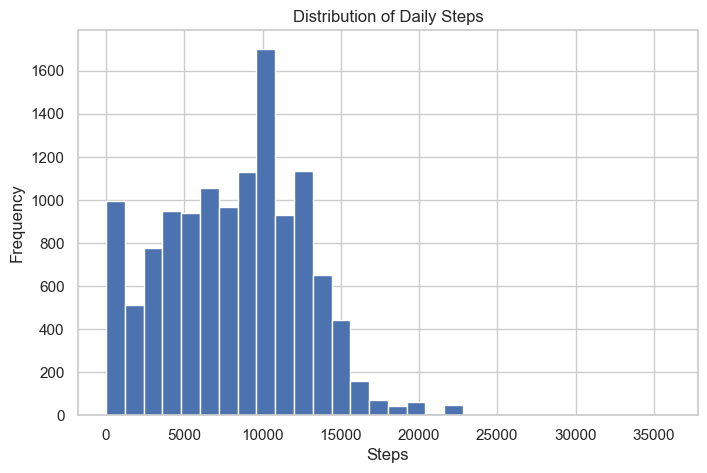

In [20]:
plt.figure(figsize=(8,5))
plt.hist(merged_df['TotalSteps'], bins=30)
plt.title("Distribution of Daily Steps")
plt.xlabel("Steps")
plt.ylabel("Frequency")
plt.show()

### Steps vs Calories

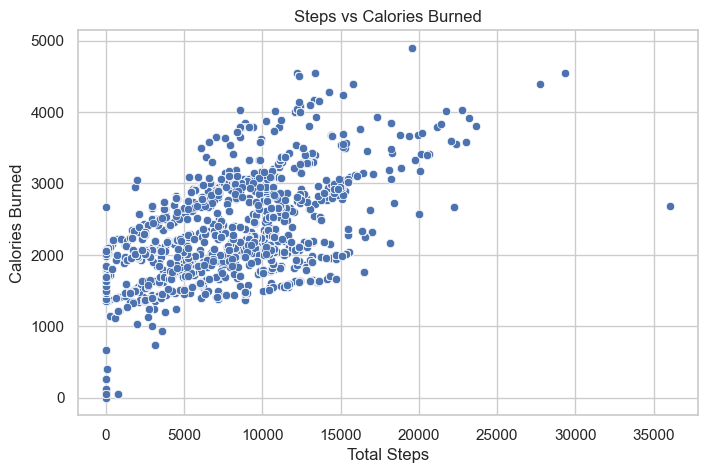

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="TotalSteps", y="Calories", data=merged_df)
plt.title("Steps vs Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")
plt.show()

Insight:
There is a positive relationship between steps taken and calories burned.
Users who walk more tend to burn more calories.

### Sleep vs Steps

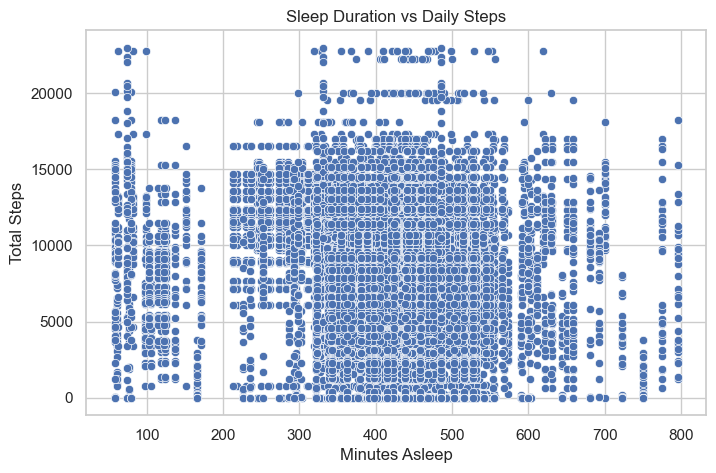

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="TotalMinutesAsleep", y="TotalSteps", data=merged_df)
plt.title("Sleep Duration vs Daily Steps")
plt.xlabel("Minutes Asleep")
plt.ylabel("Total Steps")
plt.show()

Insight:
Sleep duration varies significantly across users.
However, no strong linear relationship between sleep duration and step count is observed.

### Create Activity Level Categories

In [23]:
def activity_level(steps):
    if steps < 5000:
        return "Sedentary"
    elif steps < 10000:
        return "Moderately Active"
    else:
        return "Active"

merged_df["Activity_Level"] = merged_df["TotalSteps"].apply(activity_level)

In [24]:
merged_df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,Activity_Level
0,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,1.0,327.0,346.0,Active
1,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-13,2.0,384.0,407.0,Active
2,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-15,1.0,412.0,442.0,Active
3,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-16,2.0,340.0,367.0,Active
4,1503960366,2016-04-12,13162,8.5,8.5,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-17,1.0,700.0,712.0,Active


We see a new column Activity Level at last.

### Visualization: Activity Level Distribution

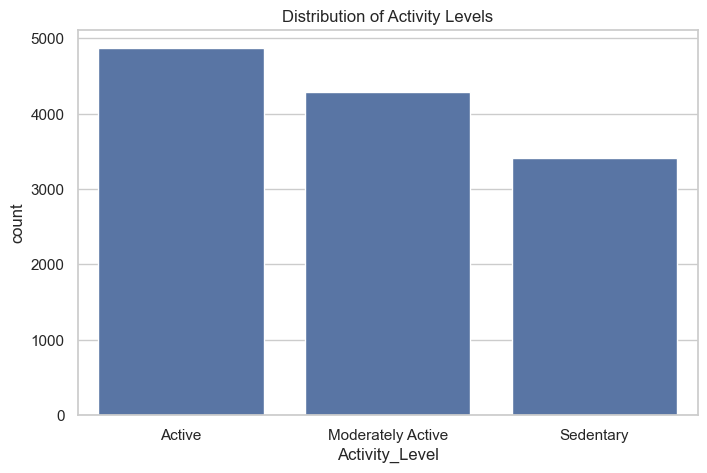

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x="Activity_Level", data=merged_df)
plt.title("Distribution of Activity Levels")
plt.show()

Insight:
Most users fall into the moderately active category.
A smaller number of users are sedentary or highly active.

### Hourly Activity Analysis

In [28]:
hourly_steps['ActivityHour'] = pd.to_datetime(
    hourly_steps['ActivityHour'],
    format='%m/%d/%Y %I:%M:%S %p'
)

hourly_steps['hour'] = hourly_steps['ActivityHour'].dt.hour

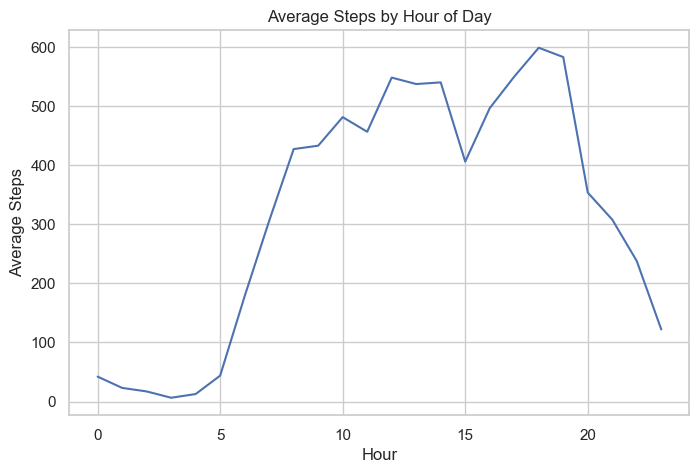

In [27]:
hourly_steps.groupby('hour')['StepTotal'].mean().plot(figsize=(8,5))
plt.title("Average Steps by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Steps")
plt.show()

Insight:
User activity tends to increase during the afternoon and evening hours.
Morning hours show lower activity levels.

### Correlation Heatmap

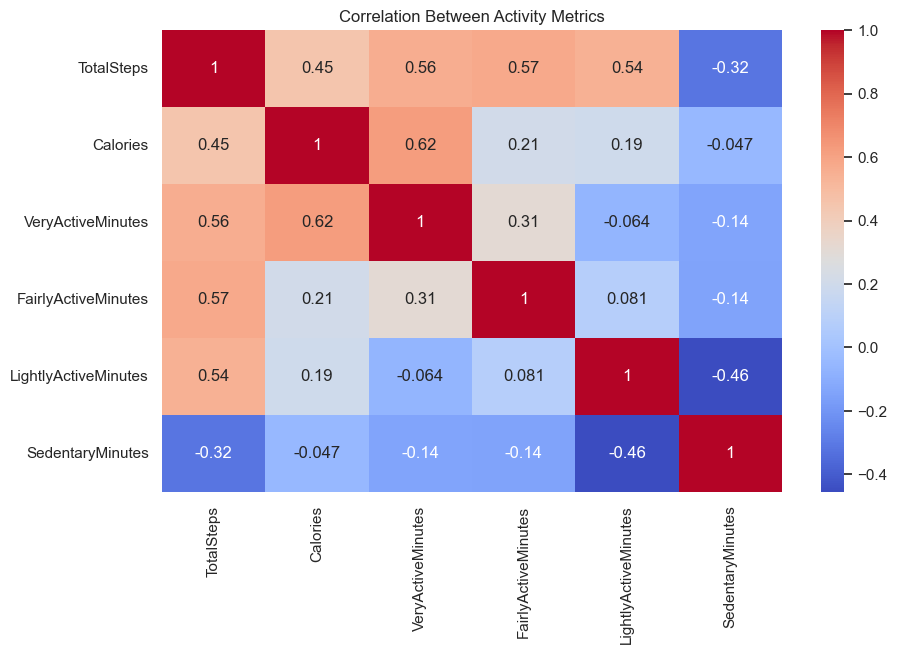

In [29]:
plt.figure(figsize=(10,6))

correlation = merged_df[
    [
        "TotalSteps",
        "Calories",
        "VeryActiveMinutes",
        "FairlyActiveMinutes",
        "LightlyActiveMinutes",
        "SedentaryMinutes"
    ]
].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Between Activity Metrics")
plt.show()

Insight:
Total steps show a strong positive correlation with calories burned.
Very active minutes also correlate strongly with calorie expenditure.
Sedentary minutes show a negative relationship with active minutes.

### Activity Minutes Distribution

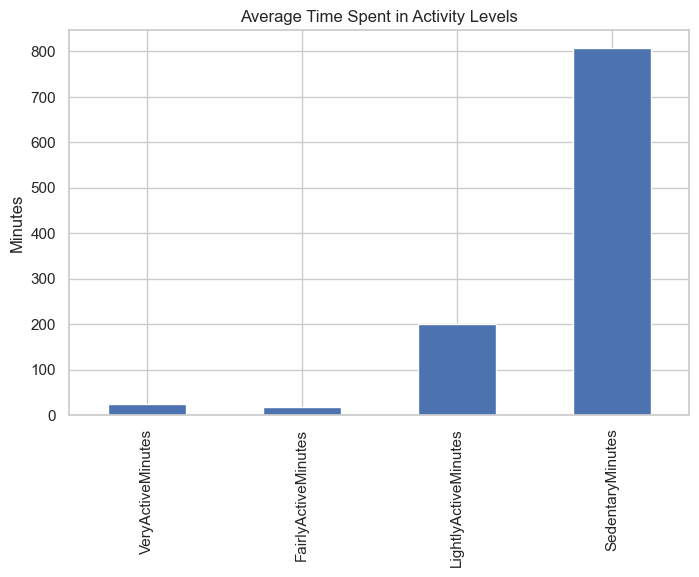

In [30]:
activity_minutes = merged_df[
    [
        "VeryActiveMinutes",
        "FairlyActiveMinutes",
        "LightlyActiveMinutes",
        "SedentaryMinutes"
    ]
].mean()

activity_minutes.plot(kind="bar", figsize=(8,5))

plt.title("Average Time Spent in Activity Levels")
plt.ylabel("Minutes")
plt.show()

Insight:
Most time is spent in sedentary or lightly active minutes.
Very active minutes are significantly lower, indicating limited intense physical activity.

### Final Insights 

Key Findings

1. Average daily steps are below the recommended 10,000 steps for many users.

2. There is a strong positive relationship between steps and calories burned.

3. Most users fall into the moderately active category.

4. Sleep duration varies widely among users.

5. Peak activity occurs during afternoon and evening hours.

## Tableau Dashboard and Charts

### Charts:

### 1. Steps Vs Calories

<img src="4.png" width="700"> 

Insights: There is a strong positive relationship between total steps and calories burned. 
Users who walk more tend to burn more calories.

### 2. Average Sleep Duration by Activity Level

<img src="5.png" width="700"> 

Insights: Users with higher activity levels tend to maintain slightly better sleep durations,
while sedentary users show more variation in sleep patterns.

### 3. Activity Level Disribution

<img src="6.png" width="700"> 

Insights: The dataset indicates that most users maintain a relatively low to moderate activity lifestyle, with limited engagement in high-intensity physical activity.

### 4. Average Steps by Day

<img src="7.png" width="700"> 

Insights: Physical activity levels fluctuate during the week, suggesting that user routines and lifestyle patterns influence daily step counts.

### 5. Sleep Duration Distriution

<img src="8.png" width="700"> 

Insights: Most users sleep between 6 and 8 hours per night, 
with the highest concentration around 7 hours of sleep.
Some users record significantly shorter or longer sleep durations.

### 6. Activity Minutes Breakdown

<img src="9.png" width="700"> 

Insights: Users spend the majority of their time in sedentary or lightly active states.
Very active minutes are significantly lower, indicating limited high-intensity activity.

## Tableau Dashboard

<img src="10.png"> 

## Key Insights

The analysis of the smart fitness device dataset revealed several important patterns in user activity and health behavior.

• Users show significant variation in daily step counts, indicating different levels of physical activity.  
• Higher step counts are generally associated with higher calorie expenditure.  
• Many users spend a large portion of their day in sedentary activity.  
• Sleep duration varies among users, but most users average around 6–7 hours of sleep.  
• Activity intensity levels suggest that light activity is more common than high-intensity workouts.

## Business Insights

Based on the analysis of user activity and sleep data, several insights can support Bellabeat's business strategy.

• Users who maintain higher activity levels tend to burn more calories and show healthier behavior patterns.  
• Encouraging users to increase their daily step count could improve engagement with fitness devices.  
• Sleep tracking features can help users monitor and improve sleep quality.  
• Personalized activity recommendations could increase user interaction with Bellabeat devices.

## Recommendations

Based on the insights obtained from the data analysis, the following recommendations can be suggested:

• Encourage users to reach daily step goals through reminders and challenges.  
• Promote sleep tracking features to improve user health awareness.  
• Provide personalized health insights based on user activity patterns.  
• Use data-driven marketing strategies to attract more users interested in fitness tracking.

## Conclusion

This project analyzed smart fitness device data using SQL, Python, and data visualization tools. 
The analysis helped uncover patterns in user activity levels, calorie expenditure, and sleep behavior.

By understanding how users interact with fitness tracking devices, companies like Bellabeat can 
develop better products and marketing strategies to promote healthier lifestyles and improve 
user engagement with smart wellness technology.